In [581]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import auc, roc_curve

In [583]:
class LogisticRegression(object):
    def __init__(self, X_train, y_train, X_test, y_test, learn_rate=0.001, n_iters=500):
        if len(X_train.shape) == 1:
            self.X_train = np.hstack((np.array([1]), X_train))
        else:
            self.X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
        self.y_train = y_train

        if len(X_test.shape) == 1:
            self.X_test = np.hstack((np.array([1]), X_test))
        else:
            self.X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))
        self.y_test = y_test

        self.learn_rate = learn_rate
        self.n_iters = n_iters 

        # Initialize model weights
        self.weight = np.zeros((self.X_train.shape[1]))

        self.accuracy_train = []  # To keep track of accuracy on the training data during gradient ascent process
        self.accuracy_test = []  # To keep track of accuracy on the test data during gradient ascent process

        self.log_likelihood_train = []  # To keep track of average log likelihood on the training data during gradient ascent process
        self.log_likelihood_test = []  # To keep track of average log likelihood on the test data during gradient ascent process

    def predict(self, samples, threshold=0.5):
        return self.predict_prob(samples) >= threshold

    def predict_prob(self, samples):
        # Todo: Compute and return the predicted probability of each sample having an income > 50K
        
        #Calculate dot product of weights and sample / Return sigmoid
        z = np.dot(samples, self.weight)
        return 1 / (1 + np.exp(-z))

    def compute_gradient(self, ):
        # Todo: compute and return gradient of the average log likelihood on the training set
        
        #Calculate predicted probabilities on the training set
        y_train_pred = self.predict_prob(self.X_train)
        
        #Calculate the error (difference between predictions and true values)
        temp = self.y_train - y_train_pred
        
        #Calculate the gradient
        grad = np.multiply(self.X_train, temp.reshape(-1, 1)) # Reshape needed for element wise multiplication
        
        #Return average overall gradient
        return np.mean(grad, axis=0)
        
    def gradient_ascent(self, ):
        # Todo: Run gradient ascent to learn model weights
        # Todo: Store the average log likelihood and the prediction accuracy 
        #       on the training and test sets after every gradient ascent iteration
        
        for i in range(self.n_iters):
            #Compute the gradient
            gradient = self.compute_gradient()

            #Update weights using gradient ascent
            self.weight += self.learn_rate * gradient
            
            #Calculate predictions
            y_train_pred = self.predict_prob(self.X_train)
            y_test_pred = self.predict_prob(self.X_test)
            
            #Calculate and store prediction accuracy
            self.accuracy_train.append(np.mean(self.predict(self.X_train) == self.y_train))
            self.accuracy_test.append(np.mean(self.predict(self.X_test) == self.y_test))
            
            #Calculate and store average log-likelihood
            ll_train = np.mean(self.y_train * np.log(y_train_pred) + (1 - self.y_train) * np.log(1 - y_train_pred))
            ll_test = np.mean(self.y_test * np.log(y_test_pred) + (1 - self.y_test) * np.log(1 - y_test_pred))

            self.log_likelihood_train.append(ll_train)
            self.log_likelihood_test.append(ll_test)

        return self

In [585]:
def preprocess_data(X_train, X_test):
    # Todo: encode categorical features using OneHotEncoder
    # Todo: standardize numerical features using StandardScaler()
    # Todo: return processed training and test sets
    
    #Identify categorical and numerical columns
    categorical = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    numerical = X_train.select_dtypes(include=['number']).columns.tolist()

    #One-Hot encode categorical features
    if categorical:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        X_train_cat = ohe.fit_transform(X_train[categorical])
        X_test_cat = ohe.transform(X_test[categorical])

        #Get new column names after one-hot encoding
        new_cat_cols = ohe.get_feature_names_out(input_features=categorical)
        X_train_cat_df = pd.DataFrame(X_train_cat, columns=new_cat_cols) #Convert back to dataframe
        X_test_cat_df = pd.DataFrame(X_test_cat, columns=new_cat_cols)
    else: #If no categorical columns, create empty dataframes
        X_train_cat_df = pd.DataFrame()
        X_test_cat_df = pd.DataFrame()

    #Normalize numerical features
    if numerical:
        scaler = StandardScaler()
        X_train_num = scaler.fit_transform(X_train[numerical])
        X_test_num = scaler.transform(X_test[numerical])

        X_train_num_df = pd.DataFrame(X_train_num, columns=numerical)
        X_test_num_df = pd.DataFrame(X_test_num, columns=numerical)
    else: #If no numerical columns, create empty dataframes
        X_train_num_df = pd.DataFrame()
        X_test_num_df = pd.DataFrame()

    #Concatenate the processed features
    processed_X_train = pd.concat([X_train_cat_df, X_train_num_df], axis=1)
    processed_X_test = pd.concat([X_test_cat_df, X_test_num_df], axis=1)

    return processed_X_train, processed_X_test

In [587]:
def plot_log_likelihood_performance(log_likelihood_train, log_likelihood_test):
    # Todo: plot the average log likelihood curves of the training and test sets
    #      during training process

    #Iteration numbers start at 1
    iterations = range(1, len(log_likelihood_train) + 1)

    #Plot curves
    plt.figure(figsize=(10, 6))
    plt.plot(iterations, log_likelihood_train, label='training logL', color='red')
    plt.plot(iterations, log_likelihood_test, label='test logL', color='blue')

    plt.title('Training Performance')
    plt.xlabel('Iterations')
    plt.ylabel('Average Log Likelihood')
    plt.legend()
    plt.grid(False)
    

In [589]:
def plot_accuracy_performance(accuracy_train, accuracy_test):
    # Todo: plot the prediction accuracy curves of the training and test sets
    #      during the training process

    #Iteration numbers start at 1
    iterations = range(1, len(accuracy_train) + 1)

    #Plot curves
    plt.figure(figsize=(10, 6))
    plt.plot(iterations, accuracy_train, label='training accuracy', color='green')
    plt.plot(iterations, accuracy_test, label='test accuracy', color='orange')

    plt.title('Training Performance - Accuracy')
    plt.xlabel('Iterations')
    plt.ylabel('Prediction Accuracy')
    plt.legend()
    plt.grid(False)

In [591]:
def plot_roc(X_train, y_train, X_test, y_test, learner):
    # Todo: plot the ROC curves 
    
    plt.figure(figsize=(10, 6))

    #Plot ROC curve for training data
    y_train_prob = learner.predict_prob(learner.X_train)
    fpr_train, tpr_train, _ = roc_curve(learner.y_train, y_train_prob)
    roc_auc_train = auc(fpr_train, tpr_train)
    plt.plot(fpr_train, tpr_train, color='red', lw=2, label=f'Training ROC curve (area = {roc_auc_train:.2f})')

    #Plot ROC curve for test data
    y_test_prob = learner.predict_prob(learner.X_test)#[:, 1]
    fpr_test, tpr_test, _ = roc_curve(learner.y_test, y_test_prob)
    roc_auc_test = auc(fpr_test, tpr_test)
    plt.plot(fpr_test, tpr_test, color='blue', lw=2, label=f'Test ROC curve (area = {roc_auc_test:.2f})')

    #Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')

    plt.xlim([0.0, 1.05])  # Set x-axis limits
    plt.ylim([0.0, 1.05])  # Set y-axis limits
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(False) 

In [593]:
# Load data
train_data = pd.read_csv('cleaned_train_data.csv')
test_data = pd.read_csv('cleaned_test_data.csv')
X_train = train_data.drop(['income'], axis=1, inplace=False)
y_train = train_data['income']
X_test = test_data.drop(['income'], axis=1, inplace=False)
y_test = test_data['income']

In [595]:
# Preprocessing data
processed_X_train, processed_X_test = preprocess_data(X_train, X_test)

In [597]:
# Run gradient ascent with Logistic Regression
learner = LogisticRegression(processed_X_train, y_train.values, processed_X_test, y_test.values,
                                 n_iters=250, learn_rate=0.75)
learner.gradient_ascent()

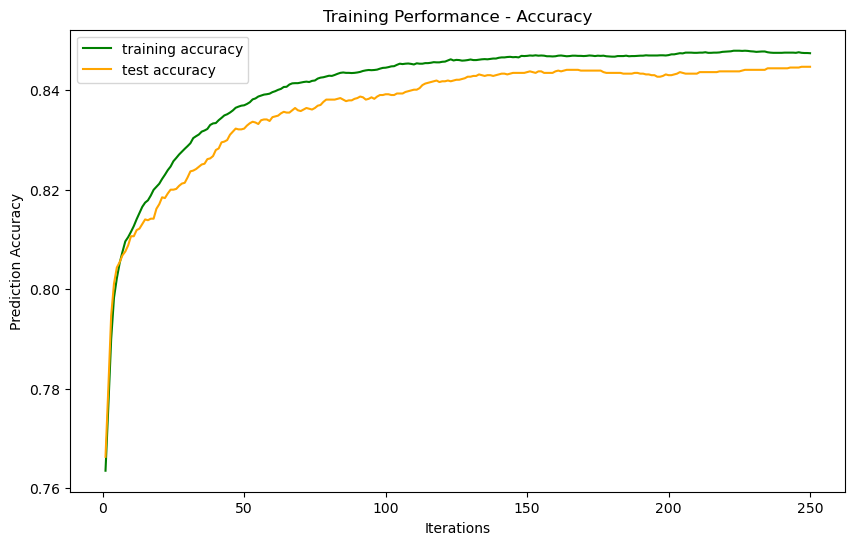

In [599]:
# Plot prediction accuracy during training process
plot_accuracy_performance(learner.accuracy_train, learner.accuracy_test)

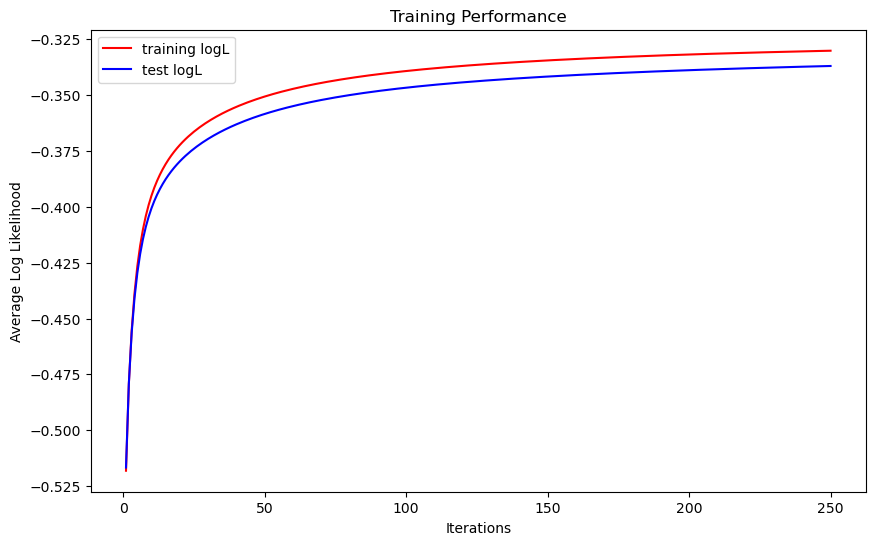

In [601]:
# Plot Log Likelihood values during training process
plot_log_likelihood_performance(learner.log_likelihood_train, learner.log_likelihood_test)

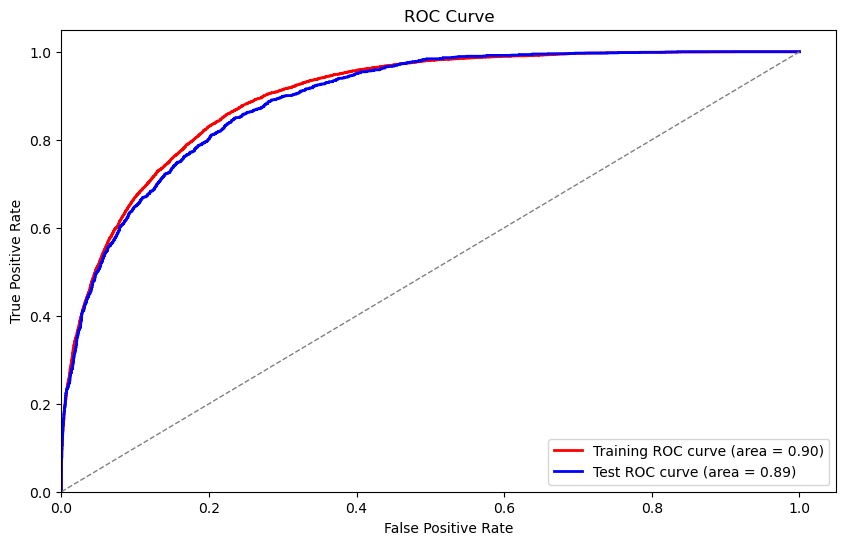

In [603]:
# Plot ROC curves
plot_roc(processed_X_train, y_train, processed_X_test, y_test, learner)